In [ ]:
!pip install sexmachine


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 336.4/336.4 kB 5.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for sexmachine: filename=SexMachine-0.1.1-py3-none-any.whl size=379440 sha256=d21f3e234c2f6c4474e0427d4da63d9c941e89f631d405314ba05c4b51055e74
  Stored in directory: /root/.cache/pip/wheels/04/b5/d0/59428a0dd67a75a0c120a72bb7fef826f11ec744ae7905bb04
Successfully built sexmachine


In [ ]:
!pip install gender-guesser


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import gender_guesser.detector as gender

# Load Data
genuine_users = pd.read_csv("/content/drive/MyDrive/fake profiles/users.csv")
fake_users = pd.read_csv("/content/drive/MyDrive/fake profiles/fusers.csv")

x = pd.concat([genuine_users, fake_users], ignore_index=True)
y = np.array([1] * len(genuine_users) + [0] * len(fake_users))

In [ ]:
# Gender Detection
detector = gender.Detector(case_sensitive=False)
def get_gender(name):
    if isinstance(name, str):
        return detector.get_gender(name.split()[0])
    return 'unknown'

gender_map = {
    'female': 1, 'mostly_female': 1,
    'male': 0, 'mostly_male': 0,
    'andy': -1, 'unknown': -1
}
x['gender'] = x['name'].apply(get_gender).map(gender_map).fillna(-1)

In [ ]:
# Feature Selection
features = ['statuses_count', 'followers_count', 'friends_count',
            'favourites_count', 'listed_count', 'gender']
lang_encoded = pd.get_dummies(x['lang'], prefix='lang')
x = pd.concat([x[features], lang_encoded], axis=1)

# Feature Engineering: Polynomial Features
poly = PolynomialFeatures(degree=2, include_bias=False)
x_poly = poly.fit_transform(x)

In [ ]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(x_poly, y, test_size=0.2, stratify=y, random_state=42)

# Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# SVM with Hyperparameter Tuning
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.001],
    'kernel': ['rbf']
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(SVC(), param_grid, cv=cv, scoring='accuracy', n_jobs=-1)
grid.fit(X_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}


In [ ]:
# Evaluation
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test_scaled)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Test Accuracy: 0.9911347517730497
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       268
           1       1.00      0.98      0.99       296

    accuracy                           0.99       564
   macro avg       0.99      0.99      0.99       564
weighted avg       0.99      0.99      0.99       564



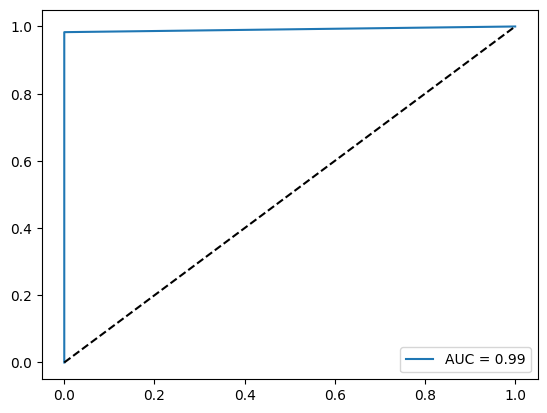

In [ ]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.legend()
plt.show()

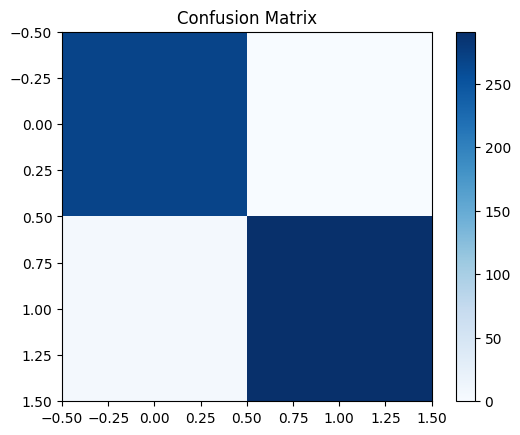

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure()
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.title('Confusion Matrix')
plt.show()